#### Name: Jon Stowers

# PHYS 230 Lab Assignment 15

### Wednesday, April 1, 2026: Chapter 8.2-8.3
- Multivariable differential equations
- Second-order differential equations 

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a second-order ordinary differential equation for a simple harmonic oscillator. The standard equation is given as: 

$$\frac{d^2x}{dt^2}= -\omega^2 x $$

The general solution to this differential equation is: 

$$x(t) = c_1 \cos \omega t + c_2 \sin \omega t $$

where $c_1$ and $c_2$ can be found from initial conditions. 

For this problem, we will analyze the case of $\omega = 1$ in the range of $t=0$ to $t=50$. The initial conditions are $x=1$ and $dx/dt = 0$. 

*Problem adapted from Exercise 8.6 in the textbook*

### Part 1: Solving the second-order differential equation 

Let's solve for $x$ as a function of time. Do this in the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. 
*Double-check with the professor before moving on.*


$\frac{dx}{dt} = v$

$\frac{dv}{dt} = -\omega^2x$


#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1. 

In [35]:
#define constants

omega = 1


#define function
def f(r,t):
    x = r[0]
    v = r[1]

    fx = v
    fv = -omega**2 * x

    return np.array([fx,fv],float) #so index 0 relates to position and index 1 relates to velocity



#### Step 3: Write a function `RK4_multi(r,t,h,f)` - like you did in the last lab - that you can use to solve any two simultaneous single-order differential equations.  

In [36]:

def RK4_multi(r,t,h,f):
    #r is an array that goes into the function as the initial conditions
    #r is 2 dimensional

    rpoints = np.zeros([len(t),2],float)

    for i in range(len(t)): 
        rpoints[i,:] = [r[0],r[1]]
        k1 = h*f(r,t[i])
        k2 = h*f(r+0.5*k1,t[i]+0.5*h)
        k3 = h*f(r+0.5*k2,t[i]+0.5*h)
        k4 = h*f(r+k3,t[i]+h)
        r += 1/6 * (k1+2*k2+2*k3+k4)
    
    return rpoints #returns a [N,2] dimensional array where [:,0] is position and [:,1] is veclocity.




#### Step 4: Define any constants and arrays necessary for the problem and solve for $x$ and $dx/dt$ as a function of time. 

In [37]:
#define constants

omega = 1
tstart = 0
tend = 50

Nsteps = 1000 #the number of steps

h = (tend-tstart)/Nsteps

tpoints = np.arange(tstart,tend+h,h)

rinitial = np.array([1,0],float) #initial condition

rpoints = RK4_multi(rinitial,tpoints,h,f) 




#### Step 5: Make a plot the position $x$ vs. time. Does this agree with what you expected (add a markdown cell explaining this)? 

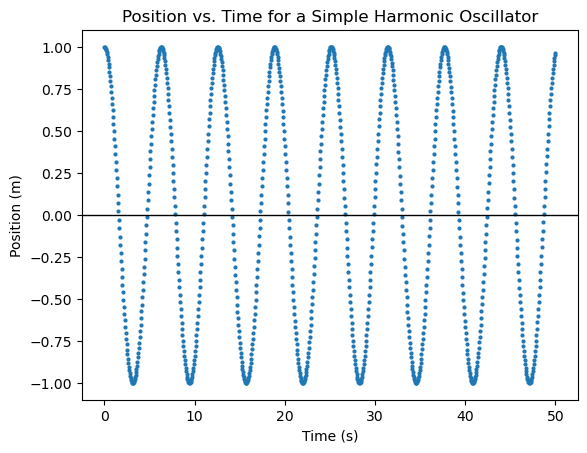

In [38]:

plt.scatter(tpoints,rpoints[:,0],s=4)
plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Position vs. Time for a Simple Harmonic Oscillator')
plt.axhline(0,linewidth=1,c='black')
plt.show()



This plot does agree with my expectations. By inspection, the solution to a differential equation $a=-\omega^2x$ should be sinusoidal. This is a cosine function, which matches with this expectation.

#### Step 6: Now graph $dx/dt$ vs. $x$ instead. This is called a *phase space* plot. Interpret the result (do an internet search to understand phase space plots if need be, but your explanations must be in your own words). 

If you would like to make your graph square, you can use: 
`plt.figure(figsize=(#,#))` replacing the #'s with whatever equal dimensions you want. 

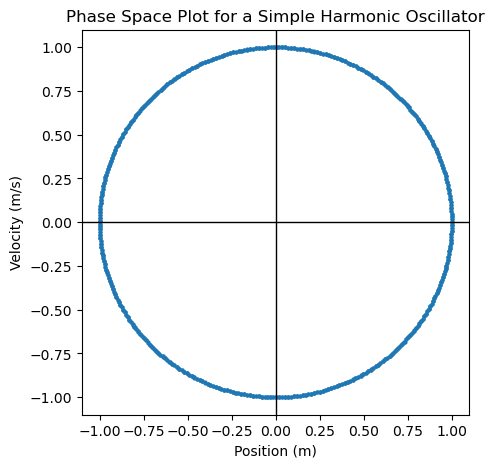

In [39]:
plt.figure(figsize=(5,5))
plt.scatter(rpoints[:,0],rpoints[:,1],s=4)
plt.ylabel('Velocity (m/s)')
plt.xlabel('Position (m)')
plt.title('Phase Space Plot for a Simple Harmonic Oscillator')
plt.axhline(0,linewidth=1,c='black')
plt.axvline(0,linewidth=1,c='black')
plt.show()


A phase space portrait, as shown above, illustrates how the position and velocity of a physical system are related. The above plot shows how the position and velocity change with respect to one another in the system. A point on this circle shows how position (a cosine function) and velocity (the derivative of position, so a sine function) add up. Since $\sin^2+\cos^2=1$ always, the radius of this phase space portrait is constant.

### Part 2: Variations

Test what happens to your solution when we change some parameters. 

#### Step 1: Increase the amplitude of oscillators by making the initial position larger. Reanalyze the results and plot $x$ vs. $t$ again. What can you say about the oscillations? In particular, comment on the period of oscillations - what do we expect to happen to the period when the amplitude is increased?  

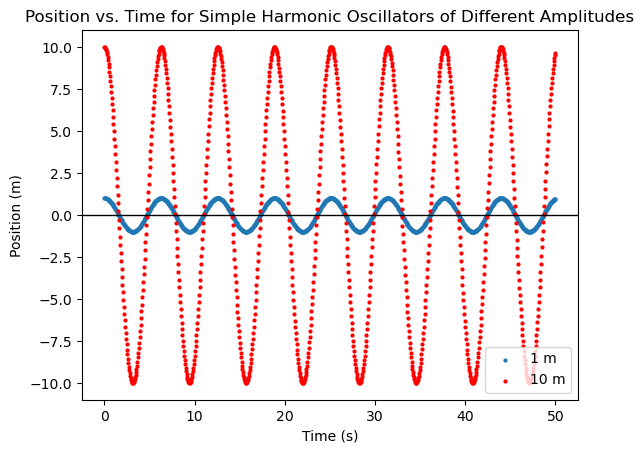

In [31]:


#define constants

omega = 1
tstart = 0
tend = 50

Nsteps = 1000 #the number of steps

h = (tend-tstart)/Nsteps

tpoints = np.arange(tstart,tend+h,h)

rinitial2 = np.array([10,0],float) #initial condition. The position here is larger, at 10 instead of 1.

rpoints2 = RK4_multi(rinitial2,tpoints,h,f) 


plt.scatter(tpoints,rpoints[:,0],s=4,label='1 m')
plt.scatter(tpoints,rpoints2[:,0],s=4,c='r',label='10 m')
plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Position vs. Time for Simple Harmonic Oscillators of Different Amplitudes')
plt.legend()
plt.axhline(0,linewidth=1,c='black')
plt.show()

Although the amplitude is larger, the period of the oscillations is the same as before! The angular frequency $\omega$ in the second-order differential equation does not depend on amplitude, so the differential equation has no dependence on the amplitude. So changing the amplitude only affects the positions and not the frequency of oscillations.

#### Step 2: Using the original amplitude, change the initial conditions to be $x = 0$ and $dx/dt = 1$. Analyze the results and plot position vs. time again. What do you notice about the oscillations compared to the previous step and the original in Part 1?

(You may find it helpful to plot the original results from Part 1 simultaneously on the same graph for comparison)

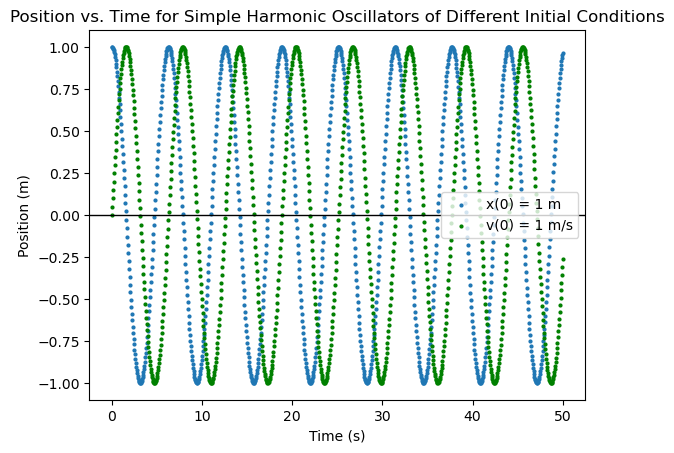

In [32]:

#define constants

omega = 1
tstart = 0
tend = 50

Nsteps = 1000 #the number of steps

h = (tend-tstart)/Nsteps

tpoints = np.arange(tstart,tend+h,h)

rinitial3 = np.array([0,1],float) #initial condition. Note that the position and velocity are "swapped"

rpoints3 = RK4_multi(rinitial3,tpoints,h,f) 



plt.scatter(tpoints,rpoints[:,0],s=4,label='x(0) = 1 m')
plt.scatter(tpoints,rpoints3[:,0],s=4,c='g',label='v(0) = 1 m/s')
plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Position vs. Time for Simple Harmonic Oscillators of Different Initial Conditions')
plt.legend()
plt.axhline(0,linewidth=1,c='black')
plt.show()

The oscillations are the same, but phase shifted by 1/4 of a period. Considering the phase space portrait from Part 1, Step 6, the only difference between the two graphs is that they start at a different point on the circle.

### Part 3: Anharmonic Oscilator 

Let's now analyze the motion of an anharmonic oscillator described by the equations
$$ \frac{d^2x}{dt} = -\omega^2 x^3 $$
Again, analyze the case of $\omega = 1$ in the range of $t=0$ to $t=30$. The initial conditions are $x=1$ and $dx/dt = 0$. 

#### Step 1: Make a graph of $x$ vs. $t$ by applying steps 1-5 from part 1 above for this new equation. 
**Hint**: You can/should reuse your `RK4_Multi` function rather than coding it up again, but be sure to complete all 5 steps 

$\frac{dx}{dt}=v$

$\frac{dv}{dt} = -\omega^2x^3$

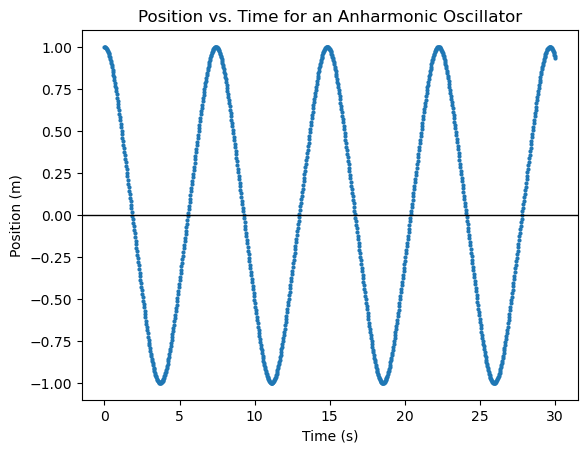

In [40]:
#define constants

omega = 1

#define function
def f(r,t):
    x = r[0]
    v = r[1]

    fx = v
    fv = -omega**2 * x**3

    return np.array([fx,fv],float) #so index 0 relates to position and index 1 relates to velocity



tstart = 0
tend = 30

Nsteps = 1000 #the number of steps

h = (tend-tstart)/Nsteps

anhtpoints = np.arange(tstart,tend+h,h)

anhrinitial = np.array([1,0],float) #initial condition

anhrpoints = RK4_multi(anhrinitial,anhtpoints,h,f) 




plt.scatter(anhtpoints,anhrpoints[:,0],s=4)
plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Position vs. Time for an Anharmonic Oscillator')
plt.axhline(0,linewidth=1,c='black')
plt.show()





#### Step 2: Once again, vary the amplitude to see what happens when we increase the amplitude from $x=1$ to $x=2$ to $x=4$. Plot all three position vs. time graphs on the same graph (be sure to include a legend). What do you notice about an anharmonic oscillator as the amplitude increases? 

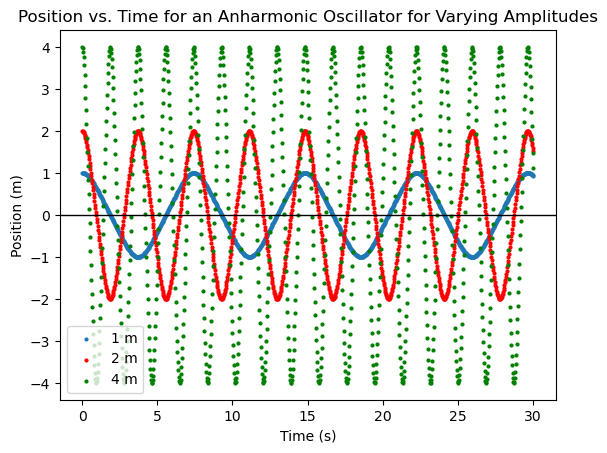

In [41]:

tstart = 0
tend = 30

Nsteps = 1000 #the number of steps

h = (tend-tstart)/Nsteps

anhtpoints = np.arange(tstart,tend+h,h)

anhrinitial2 = np.array([2,0],float) #initial condition with amplitude 2
anhrinitial3 = np.array([4,0],float) #initial condition with amplitude 4

anhrpoints2 = RK4_multi(anhrinitial2,anhtpoints,h,f) 
anhrpoints3 = RK4_multi(anhrinitial3,anhtpoints,h,f) 




plt.scatter(anhtpoints,anhrpoints[:,0],s=4,label='1 m')
plt.scatter(anhtpoints,anhrpoints2[:,0],s=4,c='r',label='2 m')
plt.scatter(anhtpoints,anhrpoints3[:,0],s=4,c='g',label='4 m')
plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Position vs. Time for an Anharmonic Oscillator for Varying Amplitudes')
plt.axhline(0,linewidth=1,c='black')
plt.legend()
plt.show()




For an anharmonic oscillator, increasing the amplitude does change the period. The period of oscillation decreases for higher amplitudes. This change is likely due to the graph no longer being sinusoidal.

#### Step 3: Now graph the *phase space* plot of the anharmonic oscillator. Include the phase space of the harmonic oscillator. In markdown, interpret the result and compare with the harmonic oscillator phase space plot. (Do this for the *original* initial conditions - they need to be the same to properly compare)

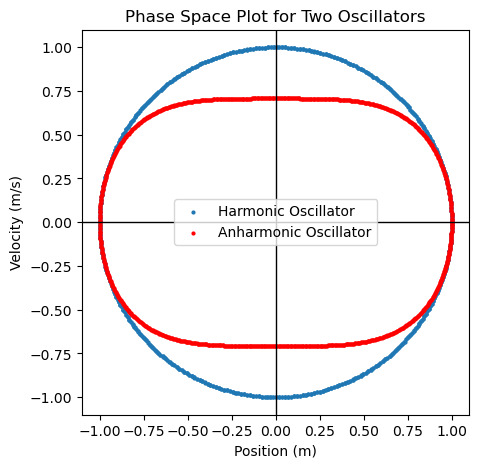

In [43]:


plt.figure(figsize=(5,5))
plt.scatter(rpoints[:,0],rpoints[:,1],s=4,label='Harmonic Oscillator')
plt.scatter(anhrpoints[:,0],anhrpoints[:,1],s=4,c='r',label='Anharmonic Oscillator')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Position (m)')
plt.title('Phase Space Plot for Two Oscillators')
plt.axhline(0,linewidth=1,c='black')
plt.axvline(0,linewidth=1,c='black')
plt.legend()
plt.show()




The results show that the anharmonic oscillator and the harmonic oscillator are similar sometimes, but not always so. It makes sense that as the position reaches the amplitude, the velocity approaches zero for both oscillators. So the left and right sides of the graphs apear the same. but the velocities (or the slopes of the position graphs) are different. As we can see in the graph for part 3, step 1, the maximum slope of the anharmonic oscillator is less than the maximum slope of the harmonic oscillator. So it makes sense that, with the pointier shape of the anharmonic oscillator, it approaches its maximum velocity more quickly than the harmonic oscillator does.